#Six - Louvre Museum Comparison
#What Makes a Painting Display Worthy at the Louvre Museum?
#A Comparative Analysis Against The Metropolitan Museum of Art

This notebook collects painting data from the Louvre Museum's collections API and compares display patterns against the findings from the Met Museum analysis in notebooks one to five.

The Louvre has 10,968 paintings in its collection versus the Met's 9,005, making it an ideal comparator. Both are large art museums with significant European paintings collections.

#Steps in this notebook:
1. ARK IDs for all paintings have already been scraped and saved to data/raw/louvre_ark_ids.csv
2. The full API enrichment has already been run and saved to data/raw/louvre_paintings_raw.csv
3. Clean and engineer features to match the Met dataset structure
4. Derive the is_on_display target variable from room/location data
5. Compare display rates across key dimensions: department, nationality, size, acquisition type
6. Test whether the Christian subjects finding holds at the Louvre as it does at the Met

#Data source: Louvre Collections - https://collections.louvre.fr
#API docs: https://collections.louvre.fr/en/page/documentationJSON
#Licence: https://collections.louvre.fr/en/page/cgu

#Note: Louvre content is solely in French. Acquisition modes are recoded to English equivalents for comparison.

#Note - Met Display Data Patch

The Met CSVs were corrupted when notebook one was interrupted and rerun during the validation check. Restored the correct is_on_display values from the Tableau export, which was saved before the corruption. Already done -- cells two and three below don't need running again.

In [2]:
import pandas as pd

df_met = pd.read_csv("data/clean/met_paintings_clean.csv")
df_louvre = pd.read_csv("data/clean/louvre_paintings_clean.csv")

print(f"Met: {len(df_met):,} paintings, {df_met['is_on_display'].mean() * 100:.1f}% on display")
print(f"Louvre: {len(df_louvre):,} paintings, {df_louvre['is_on_display'].mean() * 100:.1f}% on display")

Met: 9,005 paintings, 15.3% on display
Louvre: 10,673 paintings, 26.7% on display


#Patch Code - Already Applied

Ran this once to fix the is_on_display corruption. Keeping it here for the record but running it again would overwrite the clean data with stale values.

```python
df_tableau = pd.read_csv('data/viz/tableau_paintings.csv')
df_raw = pd.read_csv('data/raw/met_paintings_raw.csv')
df_raw['is_on_display'] = df_tableau['is_on_display']
df_raw.to_csv('data/raw/met_paintings_raw.csv', index=False)
df_clean = pd.read_csv('data/clean/met_paintings_clean.csv')
df_clean['is_on_display'] = df_tableau['is_on_display']
df_clean.to_csv('data/clean/met_paintings_clean.csv', index=False)
```

#Stage one - initial setup process

In [3]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd
import numpy as np
import json
import os

#Creating the directories if they don't exist
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/clean', exist_ok=True)
os.makedirs('images', exist_ok=True)

print('Setup is complete')

Setup is complete


#Two - Scrape ARK IDs for All Paintings

The Louvre search returns 10,968 paintings across 549 pages when filtered by typology 22 (paintings). Already done -- took around 35 minutes and the IDs are saved to data/raw/louvre_ark_ids.csv. Code below is kept for reference.

URL structure: https://collections.louvre.fr/recherche?typology%5B0%5D=22&page=N

#ARK Scraping Code - Already Run

```python
ark_ids = []
total_pages = 549
errors = []

headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36'}

for page in range(1, total_pages + 1):
    url = f'https://collections.louvre.fr/recherche?typology%5B0%5D=22&page={page}'
    # ... scraping logic ...

pd.Series(ark_ids).to_csv('data/raw/louvre_ark_ids.csv', index=False, header=['ark_path'])
```

#Note

The ARK ID validation below was a one-time check before running the full enrichment. Data is already saved to louvre_paintings_clean.csv -- skip to Stage Five.

#Stage three - validate ARK ID Collection
Before running the full API enrichment, check the ARK IDs look correct and test one JSON call.
Note - Ran during data collection when louvre_ark_ids.csv was present. Converted to markdown afterwards to prevent accidental re-execution

One-time check to confirm ARK IDs loaded correctly and test a single JSON call before the full enrichment. Data is already saved to louvre_paintings_clean.csv -- skip to Stage Five.

```python
#Loading the saved ARK IDs
ark_df = pd.read_csv("data/raw/louvre_ark_ids.csv")
ark_paths = ark_df["ark_path"].tolist()

print(f"Total ARK IDs loaded: {len(ark_paths)}")
print(f"\nFirst 5 examples:")
for path in ark_paths[:5]:
    print(path)

#Testing one JSON call as an example
test_path = ark_paths[0]
test_url = f"https://collections.louvre.fr{test_path}.json"
print(f"\nTesting JSON call: {test_url}")

response = requests.get(test_url)
if response.status_code == 200:
    test_data = response.json()
    print(f"Success - keys available: {list(test_data.keys())}")
    print(f"\nTitle: {test_data.get('title', 'None')}")
    print(f"Collection: {test_data.get('collection', 'None')}")
    print(f"Room: {test_data.get('room', 'None')}")
    print(f"Current location: {test_data.get('currentLocation', 'None')}")
else:
    print(f"Number failed with status code: {response.status_code}")
```

#Stage Four - Enrich All Paintings via JSON API

Called the JSON endpoint for each ARK ID to retrieve full painting metadata. With 10,000+ paintings at a 0.1s delay this took around two hours. Already done -- results saved to data/raw/louvre_paintings_raw.csv. Code kept below for reference.

Key fields extracted: title, collection (department), room (for is_on_display), creator, dimensions, materialsAndTechniques, acquisitionDetails, dateCreated, and index (subject tags).

#API Enrichment Code - Already Run

```python
for i, ark_path in enumerate(ark_paths):
    url = f'https://collections.louvre.fr{ark_path}.json'
    # ... extraction logic ...
    if (i + 1) % 500 == 0:
        df_temp.to_csv('data/raw/louvre_paintings_raw.csv', index=False)
```

#Stage five - initial data exploration
Overview of what has been collected before cleaning.

In [ ]:
#Loading the raw data if not already in memory
df_louvre = pd.read_csv("/Users/rosswilson/Projects/ironhack/Final Project/data/clean/louvre_paintings_clean.csv")

print(f"Shape: {df_louvre.shape}")
print(f"\nDisplay rate: {df_louvre['is_on_display'].mean() * 100:.1f}%")
print(f"Paintings on display: {df_louvre['is_on_display'].sum()}")
print(f"Paintings in storage: {(df_louvre['is_on_display'] == 0).sum()}")

print(f"\nMissing values are:")
print(df_louvre.isnull().sum())

print(f"\nCollections (departments):")
print(df_louvre['collection'].value_counts())

print(f"\nSample of acquisition modes is:")
print(df_louvre['acquisition_mode'].value_counts().head(10))

Shape: (10673, 28)

Display rate: 26.7%
Paintings on display: 2854
Paintings in storage: 7819

Missing values are:
ark_id                          0
url                             0
title                           0
collection                      0
room                         7819
current_location                0
is_on_display                   0
artist_name                   102
artist_wikidata              1771
height_cm                   10519
width_cm                    10514
materials_and_techniques       54
place_of_creation           10526
provenance                  10667
acquisition_mode                5
acquisition_year             3675
start_year                    108
end_year                     4250
tags                        10585
tag_count                       0
is_mnr                          0
creation_year                  92
painting_age                   92
years_in_collection          3675
area_cm2                    10560
has_known_artist                0
a

#Stage six - data quality assessment
Before feature engineering, the raw Louvre data is assessed for quality issues that could affect the integrity of the comparative analysis. Checks cover null values, duplicate records, HTML encoding artefacts, unexpected values in key fields, and outliers in numeric columns. Then it can be accurately and scientifically compared to Met data. 

In [ ]:
# Null and missing value audit

print("Null value audit\n")
null_counts = df_louvre.isnull().sum()
null_pct = (null_counts / len(df_louvre) * 100).round(2)

null_summary = pd.DataFrame({
    'missing_count': null_counts,
    'missing_pct': null_pct
}).sort_values('missing_count', ascending=False)

print(null_summary[null_summary['missing_count'] > 0].to_string())
print(f"\nTotal rows: {len(df_louvre)}")
print(f"Columns with no missing values: {(null_counts == 0).sum()}")

In [ ]:
print(df_louvre.columns.tolist())

['ark_id', 'url', 'title', 'collection', 'room', 'current_location', 'is_on_display', 'artist_name', 'artist_wikidata', 'height_cm', 'width_cm', 'materials_and_techniques', 'place_of_creation', 'provenance', 'acquisition_mode', 'acquisition_year', 'start_year', 'end_year', 'tags', 'tag_count', 'is_mnr', 'creation_year', 'painting_age', 'years_in_collection', 'area_cm2', 'has_known_artist', 'area_quartile', 'collection_age_band']


In [ ]:
#Conducting duplicate ARK ID check

print("Duplicate audit check\n")
total_dupes = df_louvre.duplicated(subset='ark_id').sum()
print(f"Duplicate ARK IDs: {total_dupes}")

if total_dupes > 0:
    dupes = df_louvre[df_louvre.duplicated(subset='ark_id', keep=False)]
    print(f"\nAffected records:")
    print(dupes[['ark_id', 'title']].to_string())
else:
    print("No duplicate ARK IDs found. Each record is unique.")

Duplicate audit check

Duplicate ARK IDs: 0
No duplicate ARK IDs found. Each record is unique.


In [ ]:
#Dealing with HTML encoding artefact check in string fields

import re

print("Html audit\n")

text_fields = ['title', 'collection', 'acquisition_mode']
html_pattern = re.compile(r'&[a-zA-Z]+;|&#\d+;|<[^>]+>')

for col in text_fields:
    if col not in df_louvre.columns:
        print(f"{col}: column not found\n")
        continue
    
    matches = df_louvre[col].dropna().astype(str).str.contains(html_pattern)
    count = matches.sum()
    print(f"{col}: {count} potential HTML artefacts found")
    
    if count > 0:
        examples = df_louvre[col][matches].head(5).tolist()
        for ex in examples:
            print(f"  → {ex}")
    print()

Html audit

title: 0 potential HTML artefacts found

collection: 0 potential HTML artefacts found

acquisition_mode: 0 potential HTML artefacts found



In [ ]:
#Checking key fields

print("Key field audit\n")

#Making sure is_on_display should only be 0 or 1
display_vals = df_louvre['is_on_display'].value_counts(dropna=False)
print("is_on_display value counts:")
print(display_vals.to_string())
unexpected_display = df_louvre[~df_louvre['is_on_display'].isin([0, 1])]
print(f"Unexpected values: {len(unexpected_display)}\n")

#Assessing year plausibility - suggesting 500 BCE to current year is a reasonable range for paintings
import datetime
current_year = datetime.datetime.now().year

for col in ['start_year', 'end_year']:
    if col in df_louvre.columns:
        out_of_range = df_louvre[
            (df_louvre[col].notna()) &
            ((df_louvre[col] < -500) | (df_louvre[col] > current_year))
        ]
        print(f"{col} — beyond the plausible range: {len(out_of_range)}")
        if len(out_of_range) > 0:
            print(out_of_range[['ark_id', 'title', col]].head(5).to_string())
        print()

# Dimension sanity (zero or negative values)
for col in ['height_cm', 'width_cm']:
    if col in df_louvre.columns:
        bad_dims = df_louvre[df_louvre[col].notna() & (df_louvre[col] <= 0)]
        print(f"{col} — zero or negative values: {len(bad_dims)}")

Key field audit

is_on_display value counts:
is_on_display
0    7819
1    2854
Unexpected values: 0

start_year — beyond the plausible range: 1
            ark_id            title  start_year
10361  cl010281527  peinture murale     -1400.0

end_year — beyond the plausible range: 0

height_cm — zero or negative values: 0
width_cm — zero or negative values: 0


In [ ]:
# Conducting data quality summary

print("Louvre data quality summary\n")

total = len(df_louvre)
complete_rows = df_louvre.dropna().shape[0]
pct_complete = round(complete_rows / total * 100, 1)

print(f"Total records from Louvre: {total}")
print(f"Fully complete rows (no nulls): {complete_rows} ({pct_complete}%)")
print(f"Duplicate ARK IDs: {df_louvre.duplicated(subset='ark_id').sum()}")

for col in ['title', 'collection', 'acquisition_mode']:
    if col in df_louvre.columns:
        html_hits = df_louvre[col].dropna().astype(str).str.contains(html_pattern).sum()
        print(f"HTML artefacts in {col}: {html_hits}")

print(f"\nData quality check complete. Moving on to feature engineering.")

#Stage seven - feature engineering
Engineer comparable features to the Met dataset so the two collections can be compared directly.
Key features to create are as follows:
-painting_age: estimated age from creation dates
-years_in_collection: years since acquisition
-area_cm2: height x width
-has_known_artist: binary flag
-nationality_group: grouped nationality from place of creation

In [ ]:
import datetime
current_year = datetime.datetime.now().year

df = df_louvre.copy()

#Estimated creation year (midpoint of start and end)
df['creation_year'] = ((df['start_year'].fillna(df['end_year']) + 
                        df['end_year'].fillna(df['start_year'])) / 2)

#Painting age
df['painting_age'] = current_year - df['creation_year']

#Years in collection
df['years_in_collection'] = current_year - df['acquisition_year']
df['years_in_collection'] = df['years_in_collection'].clip(lower=0)

#Area
df['area_cm2'] = df['height_cm'] * df['width_cm']

#Has known artist
df['has_known_artist'] = (df['artist_name'].notna() & 
                          (df['artist_name'] != '') & 
                          (~df['artist_name'].str.lower().str.contains('inconnu|unknown|anonyme', na=False))).astype(int)

#Tag count
df['tag_count'] = df['tag_count'].fillna(0).astype(int)

#Area quartile
df_with_area = df[df['area_cm2'].notna() & (df['area_cm2'] > 0)]
df['area_quartile'] = pd.qcut(df['area_cm2'], q=4, 
                               labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)'])

#Collection age band
df['collection_age_band'] = pd.cut(df['years_in_collection'],
    bins=[0, 20, 40, 60, 80, 100, 500],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100', '100+'])

print("Feature engineering is now complete")
print(f"\nShape: {df.shape}")
print(f"\nNew features summary:")
print(df[['painting_age', 'years_in_collection', 'area_cm2', 'has_known_artist', 'tag_count']].describe())

Feature engineering is now complete

Shape: (10673, 28)

New features summary:
       painting_age  years_in_collection      area_cm2  has_known_artist  \
count  10581.000000          6998.000000    113.000000      10673.000000   
mean     334.858898           132.207917   4776.194690          0.869859   
std      190.002967            75.968213   8578.301458          0.336475   
min        7.000000             1.000000     35.000000          0.000000   
25%      213.500000            76.000000    204.000000          1.000000   
50%      311.000000           123.000000   1053.000000          1.000000   
75%      384.000000           182.000000   5440.000000          1.000000   
max     3426.000000           519.000000  54405.000000          1.000000   

          tag_count  
count  10673.000000  
mean       0.118523  
std        1.543384  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max       38.000000  


#Stage eight - saving the clean dataset

In [ ]:
df.to_csv("data/clean/louvre_paintings_clean.csv", index=False)
print(f"Saved {len(df)} paintings to data/clean/louvre_paintings_clean.csv")
print(f"Overall Louvre display rate as a percentage of overall collection is: {df['is_on_display'].mean() * 100:.1f}%")
print(f"Compare to Met display rate of 15.3%")

Saved 10673 paintings to data/clean/louvre_paintings_clean.csv
Overall Louvre display rate as a percentage of overall collection is: 26.7%
Compare to Met display rate of 15.3%


#Stage nine - adding comparative analysis of Louvre to the Met
This section will be built out once the data collection is complete.
Planned comparisons are:
1. Overall display rates
2. Display rate by department
3. Size and display
4. Collection tenure and display
5. Subject matter - does the Christian subjects finding hold at the Louvre?
6. Acquisition type and display

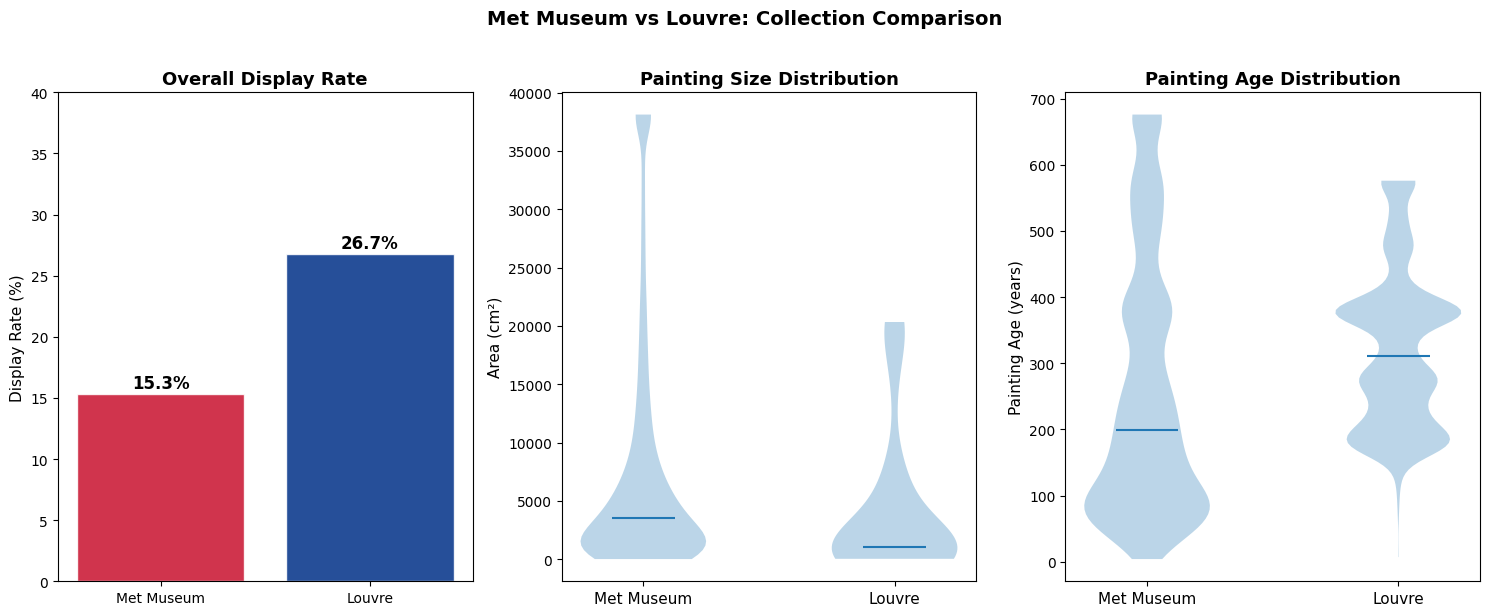

Overview comparison saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_met = pd.read_csv("/Users/rosswilson/Projects/ironhack/Final Project/data/clean/met_paintings_clean.csv")
df_louvre = pd.read_csv("/Users/rosswilson/Projects/ironhack/Final Project/data/clean/louvre_paintings_clean.csv")

#Overall display rate comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

museums = ['Met Museum', 'Louvre']
display_rates = [
    df_met['is_on_display'].mean() * 100,
    df_louvre['is_on_display'].mean() * 100
]
colours = ['#C8102E', '#003087']

axes[0].bar(museums, display_rates, color=colours, alpha=0.85, edgecolor='white')
axes[0].set_title('Overall Display Rate', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Display Rate (%)', fontsize=11)
axes[0].set_ylim(0, 40)
for i, v in enumerate(display_rates):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

#Size comparison
met_area = df_met[df_met['area_cm2'].notna()]['area_cm2'].clip(upper=df_met['area_cm2'].quantile(0.95))
louvre_area = df_louvre[df_louvre['area_cm2'].notna()]['area_cm2'].clip(upper=df_louvre['area_cm2'].quantile(0.95))

axes[1].violinplot([met_area, louvre_area], positions=[1, 2], showmedians=True, showextrema=False)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Met Museum', 'Louvre'], fontsize=11)
axes[1].set_ylabel('Area (cm²)', fontsize=11)
axes[1].set_title('Painting Size Distribution', fontsize=13, fontweight='bold')

#Painting age comparison
met_age = df_met[df_met['painting_age'].notna()]['painting_age'].clip(upper=df_met['painting_age'].quantile(0.95))
louvre_age = df_louvre[df_louvre['painting_age'].notna()]['painting_age'].clip(upper=df_louvre['painting_age'].quantile(0.95))

axes[2].violinplot([met_age, louvre_age], positions=[1, 2], showmedians=True, showextrema=False)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Met Museum', 'Louvre'], fontsize=11)
axes[2].set_ylabel('Painting Age (years)', fontsize=11)
axes[2].set_title('Painting Age Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Met Museum vs Louvre: Collection Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("images/comparison_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Overview comparison saved")

In [ ]:
import pandas as pd

df_met = pd.read_csv("/Users/rosswilson/Projects/ironhack/Final Project/data/clean/met_paintings_clean.csv")
df_louvre = pd.read_csv("/Users/rosswilson/Projects/ironhack/Final Project/data/clean/louvre_paintings_clean.csv")

print(f"Met: {len(df_met)} paintings, {df_met['is_on_display'].mean()*100:.1f}% on display")
print(f"Louvre: {len(df_louvre)} paintings, {df_louvre['is_on_display'].mean()*100:.1f}% on display")

Met: 9005 paintings, 15.3% on display
Louvre: 10673 paintings, 26.7% on display


In [4]:
df_met['area_cm2'] = df_met['height_cm'] * df_met['width_cm']
df_met['area_quartile'] = pd.qcut(df_met['area_cm2'], q=4, 
                                   labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)'])

df_louvre['area_quartile'] = pd.qcut(df_louvre['area_cm2'], q=4,
                                      labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)'])

print("Quartiles created")

Quartiles created


/var/folders/8w/jbgrr0fd4jvbmhsmhc4cb5400000gn/T/ipykernel_98376/4173011407.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  met_size = df_met.groupby('area_quartile')['is_on_display'].mean() * 100
/var/folders/8w/jbgrr0fd4jvbmhsmhc4cb5400000gn/T/ipykernel_98376/4173011407.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  louvre_size = df_louvre.groupby('area_quartile')['is_on_display'].mean() * 100


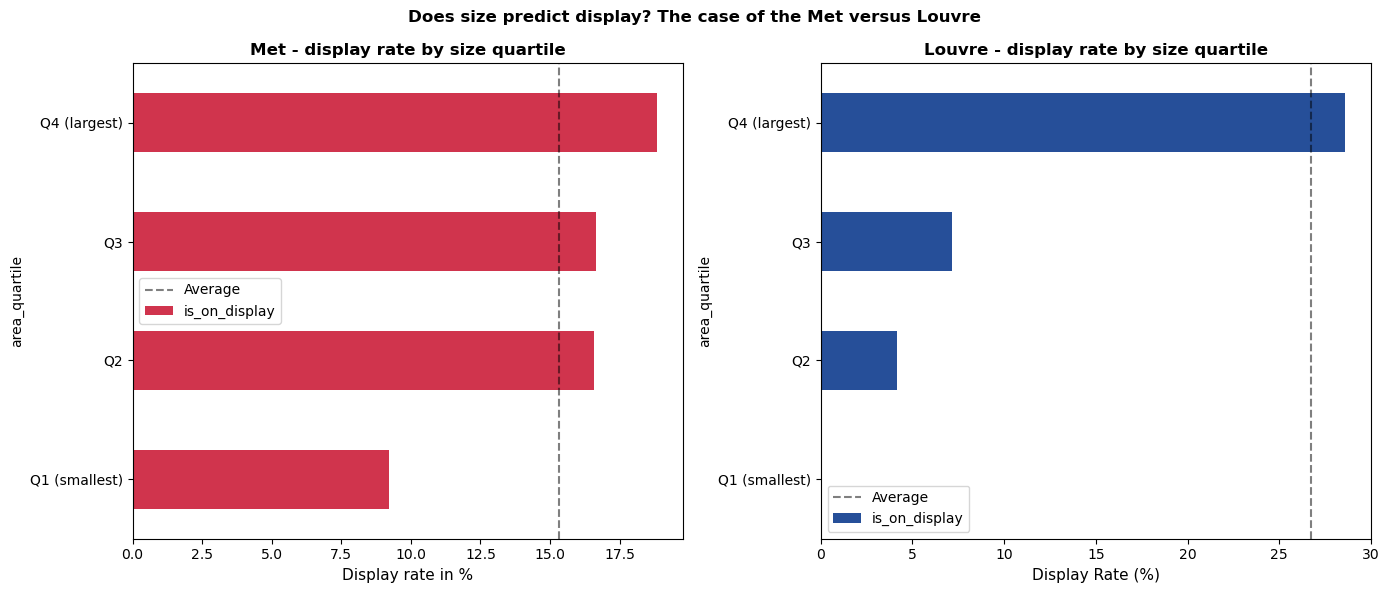

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Loading Met size quartile
met_size = df_met.groupby('area_quartile')['is_on_display'].mean() * 100
met_size.plot(kind='barh', ax=axes[0], color='#C8102E', alpha=0.85)
axes[0].set_title('Met - display rate by size quartile', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Display rate in %', fontsize=11)
axes[0].axvline(x=df_met['is_on_display'].mean()*100, color='black', linestyle='--', alpha=0.5, label='Average')
axes[0].legend()

#Loading Louvre size quartile
louvre_size = df_louvre.groupby('area_quartile')['is_on_display'].mean() * 100
louvre_size.plot(kind='barh', ax=axes[1], color='#003087', alpha=0.85)
axes[1].set_title('Louvre - display rate by size quartile', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Display Rate (%)', fontsize=11)
axes[1].axvline(x=df_louvre['is_on_display'].mean()*100, color='black', linestyle='--', alpha=0.5, label='Average')
axes[1].legend()

plt.suptitle('Does size predict display? The case of the Met versus Louvre', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("images/comparison_size.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Acquisition type comparison

# Standardising Louvre acquisition modes into English equivalents
acquisition_map = {
    'achat': 'Purchase',
    'legs': 'Bequest',
    'don': 'Gift',
    'donation': 'Gift',
    'dation': 'Gift',
    'ancienne collection': 'Historic Collection',
    'ancienne collection royale/de la Couronne': 'Historic Collection',
    'entrée - Collection de Louis XIV': 'Historic Collection',
    'saisie révolutionnaire': 'Historic Collection',
    "attribution par l'office des biens et intérêts privés (MNR)": 'MNR Recovery',
    'mode d\'acquisition inconnu': 'Unknown'
}

df_louvre['acquisition_type_en'] = df_louvre['acquisition_mode'].map(acquisition_map).fillna('Other')

# Calculate averages dynamically
met_avg = df_met['is_on_display'].mean() * 100
louvre_avg = df_louvre['is_on_display'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Met
met_acq = df_met.groupby('acquisition_type')['is_on_display'].mean() * 100
met_acq = met_acq[met_acq.index != 'Unknown'].sort_values(ascending=True)
met_acq.plot(kind='barh', ax=axes[0], color='#C8102E', alpha=0.85)
axes[0].set_title('Met - display rate by acquisition type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Display rate (%)', fontsize=11)
axes[0].axvline(x=met_avg, color='black', linestyle='--', alpha=0.5, label=f'Average {met_avg:.1f}%')
axes[0].legend()

# Louvre
louvre_acq = df_louvre.groupby('acquisition_type_en')['is_on_display'].mean() * 100
louvre_acq = louvre_acq[louvre_acq.index != 'Unknown'].sort_values(ascending=True)
louvre_acq.plot(kind='barh', ax=axes[1], color='#003087', alpha=0.85)
axes[1].set_title('Louvre - display rate by acquisition type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Display rate (%)', fontsize=11)
axes[1].axvline(x=louvre_avg, color='black', linestyle='--', alpha=0.5, label=f'Average {louvre_avg:.1f}%')
axes[1].legend()

plt.suptitle('Does acquisition type predict display? Met versus Louvre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/comparison_acquisition.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Acquisition type vs display rate: Met vs Louvre - styled chart

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Georgia', 'Times New Roman'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.grid': False,
    'figure.facecolor': '#f7f4f0',
    'axes.facecolor': '#f7f4f0',
    'xtick.color': '#888888',
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
})

MET_COLOR    = '#C8253A'
LOUVRE_COLOR = '#1A3A6B'
MET_AVG      = round(df_met['is_on_display'].mean() * 100, 1)
LOUVRE_AVG   = round(df_louvre['is_on_display'].mean() * 100, 1)

shared_labels   = ['Other', 'Bequest', 'Gift']
met_vals        = [35, 29, 9]
louvre_vals     = [31, 23, 30]

specific_labels = ['Purchase / Fund', 'Historic Collection', 'Purchase', 'MNR Recovery']
specific_met    = [13, None, None, None]
specific_louvre = [None, 30, 27, 11]

all_labels = shared_labels + [''] + specific_labels
all_met    = met_vals + [None] + specific_met
all_louvre = louvre_vals + [None] + specific_louvre

n_shared = len(shared_labels)
ys = np.arange(len(all_labels))[::-1].astype(float)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#f7f4f0')
ax.set_facecolor('#f7f4f0')

h = 0.3

for i, (label, mv, lv) in enumerate(zip(all_labels, all_met, all_louvre)):
    y = ys[i]
    if label == '':
        continue
    if mv is not None:
        ax.barh(y + h/2 + 0.02, mv, height=h, color=MET_COLOR, alpha=0.88)
        ax.text(mv + 0.4, y + h/2 + 0.02, f'{mv}%', va='center', fontsize=8.5, color=MET_COLOR)
    else:
        ax.barh(y + h/2 + 0.02, 0.5, height=h, color='#ddd')
        ax.text(1, y + h/2 + 0.02, 'n/a', va='center', fontsize=8, color='#aaa')
    if lv is not None:
        ax.barh(y - h/2 - 0.02, lv, height=h, color=LOUVRE_COLOR, alpha=0.88)
        ax.text(lv + 0.4, y - h/2 - 0.02, f'{lv}%', va='center', fontsize=8.5, color=LOUVRE_COLOR)
    else:
        ax.barh(y - h/2 - 0.02, 0.5, height=h, color='#ddd')
        ax.text(1, y - h/2 - 0.02, 'n/a', va='center', fontsize=8, color='#aaa')

ax.axvline(MET_AVG,    color=MET_COLOR,    linestyle='--', linewidth=0.9, alpha=0.45)
ax.axvline(LOUVRE_AVG, color=LOUVRE_COLOR, linestyle='--', linewidth=0.9, alpha=0.45)
ax.text(MET_AVG + 0.3,    ys[0] + 0.9, f'Met avg {MET_AVG}%',    fontsize=8, color=MET_COLOR,    alpha=0.7)
ax.text(LOUVRE_AVG + 0.3, ys[0] + 0.7, f'Louvre avg {LOUVRE_AVG}%', fontsize=8, color=LOUVRE_COLOR, alpha=0.7)

divider_y = ys[n_shared] - 0.0
ax.axhline(divider_y, color='#cccccc', linewidth=0.8, linestyle=':')
ax.text(40.5, divider_y + 0.15, 'Shared categories',    fontsize=8, color='#999', ha='right', style='italic')
ax.text(40.5, divider_y - 0.55, 'Institution-specific', fontsize=8, color='#999', ha='right', style='italic')

tick_positions = [ys[i] for i, l in enumerate(all_labels) if l != '']
tick_labels    = [l for l in all_labels if l != '']
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, fontsize=10)
ax.set_xlim(0, 42)
ax.set_xlabel('Display rate (%)', fontsize=10, color='#555')
ax.spines['bottom'].set_color('#cccccc')

met_patch    = plt.Rectangle((0,0), 1, 1, fc=MET_COLOR, alpha=0.88)
louvre_patch = plt.Rectangle((0,0), 1, 1, fc=LOUVRE_COLOR, alpha=0.88)
ax.legend([met_patch, louvre_patch], ['The Met', 'The Louvre'],
          fontsize=9, frameon=False, loc='lower right')

ax.set_title('Does acquisition type predict display?\nThe Met versus the Louvre',
             fontsize=13, fontfamily='serif', loc='left', pad=14, color='#1a1a1a')

plt.tight_layout()
plt.savefig('images/acquisition_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

In [ ]:
#Running statistical comparison: acquisition type vs display rate, Met versus Louvre

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

met    = pd.read_csv('/Users/rosswilson/Projects/ironhack/Final Project/data/clean/met_paintings_clean.csv')
louvre = pd.read_csv('/Users/rosswilson/Projects/ironhack/Final Project/data/clean/louvre_paintings_clean.csv')

print("Met columns:",    met.columns.tolist())
print("Louvre columns:", louvre.columns.tolist())

Met columns: ['object_id', 'title', 'artist_name', 'object_begin_date', 'object_end_date', 'painting_age', 'creation_year', 'height_cm', 'width_cm', 'area_cm2', 'accession_year', 'years_in_collection', 'artist_work_count', 'tag_count', 'is_public_domain', 'is_highlight', 'department', 'has_known_artist', 'primary_medium', 'support', 'nationality_group', 'acquisition_type', 'tag_men', 'tag_women', 'tag_landscapes', 'tag_portraits', 'tag_mountains', 'tag_trees', 'tag_flowers', 'tag_birds', 'tag_horses', 'tag_abstraction', 'tag_count.1', 'is_on_display', 'medium', 'culture', 'period', 'tags', 'gallery_number', 'credit_line']
Louvre columns: ['ark_id', 'url', 'title', 'collection', 'room', 'current_location', 'is_on_display', 'artist_name', 'artist_wikidata', 'height_cm', 'width_cm', 'materials_and_techniques', 'place_of_creation', 'provenance', 'acquisition_mode', 'acquisition_year', 'start_year', 'end_year', 'tags', 'tag_count', 'is_mnr', 'creation_year', 'painting_age', 'years_in_collec

In [ ]:
#Chi-squared and Cramer's V: acquisition type vs display rate

def cramers_v(contingency_table):
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    k = min(contingency_table.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    return chi2, p, dof, v

met_ct    = pd.crosstab(met['acquisition_type'], met['is_on_display'])
louvre_ct = pd.crosstab(louvre['acquisition_mode'], louvre['is_on_display'])

met_chi2, met_p, met_dof, met_v       = cramers_v(met_ct)
louvre_chi2, louvre_p, louvre_dof, louvre_v = cramers_v(louvre_ct)

print("Met museum")
print(f"  Chi-squared : {met_chi2:.2f}")
print(f"  p-value     : {met_p:.4f}")
print(f"  Degrees of freedom: {met_dof}")
print(f"  Cramer's V  : {met_v:.3f}")

print("\n# Louvre museum")
print(f"  Chi-squared : {louvre_chi2:.2f}")
print(f"  p-value     : {louvre_p:.4f}")
print(f"  Degrees of freedom: {louvre_dof}")
print(f"  Cramer's V  : {louvre_v:.3f}")

print("\n# Interpretation")
for name, v in [("Met", met_v), ("Louvre", louvre_v)]:
    if v < 0.1:
        strength = "negligible"
    elif v < 0.2:
        strength = "weak"
    elif v < 0.4:
        strength = "moderate"
    else:
        strength = "strong"
    print(f"  {name}: Cramer's V = {v:.3f} ({strength} association)")

Met museum
  Chi-squared : 595.36
  p-value     : 0.0000
  Degrees of freedom: 4
  Cramer's V  : 0.257

# Louvre museum
  Chi-squared : 1692.79
  p-value     : 0.0000
  Degrees of freedom: 78
  Cramer's V  : 0.398

# Interpretation
  Met: Cramer's V = 0.257 (moderate association)
  Louvre: Cramer's V = 0.398 (moderate association)


In [ ]:
print(louvre['acquisition_mode'].value_counts())
print(f"\nTotal categories: {louvre['acquisition_mode'].nunique()}")
print(f"Categories with fewer than 10 paintings: {(louvre['acquisition_mode'].value_counts() < 10).sum()}")

acquisition_mode
achat                                                          1613
legs                                                           1449
don                                                             873
attribution par l'office des biens et intérêts privés (MNR)     790
ancienne collection                                             723
                                                               ... 
renonciation à l'usufruit                                         1
souscription nationale                                            1
achat sur les arrérages d'une donation                            1
cession des domaines                                              1
affectation pour Orsay                                            1
Name: count, Length: 79, dtype: int64

Total categories: 79
Categories with fewer than 10 paintings: 27


In [ ]:
#Recoding Louvre acquisition_mode into Met-equivalent buckets

purchase_terms  = ['achat', 'acquisition']
bequest_terms   = ['legs']
gift_terms      = ['don', 'donation', 'dation']
mnr_terms       = ['mnr', 'biens et intérêts']
historic_terms  = ['ancienne collection']

def recode_louvre(mode):
    if not isinstance(mode, str):
        return 'Other'
    m = mode.lower()
    if any(t in m for t in mnr_terms):
        return 'MNR Recovery'
    if any(t in m for t in bequest_terms):
        return 'Bequest'
    if any(t in m for t in gift_terms):
        return 'Gift'
    if any(t in m for t in purchase_terms):
        return 'Purchase / Fund'
    if any(t in m for t in historic_terms):
        return 'Historic Collection'
    return 'Other'

louvre['acquisition_type_recoded'] = louvre['acquisition_mode'].apply(recode_louvre)

print(louvre['acquisition_type_recoded'].value_counts())
print(f"\nTotal categories after recoding: {louvre['acquisition_type_recoded'].nunique()}")

acquisition_type_recoded
Other                  3092
Purchase / Fund        2355
Gift                   1765
Bequest                1551
Historic Collection    1120
MNR Recovery            790
Name: count, dtype: int64

Total categories after recoding: 6


In [ ]:
#Reruning chi-squared and Cramer's V on recoded Louvre categories

louvre_ct_recoded = pd.crosstab(louvre['acquisition_type_recoded'], louvre['is_on_display'])

louvre_chi2_r, louvre_p_r, louvre_dof_r, louvre_v_r = cramers_v(louvre_ct_recoded)

print("# Louvre (recoded)")
print(f"  Chi-squared        : {louvre_chi2_r:.2f}")
print(f"  p-value            : {louvre_p_r:.4f}")
print(f"  Degrees of freedom : {louvre_dof_r}")
print(f"  Cramer's V         : {louvre_v_r:.3f}")

print("\n# Direct comparison")
print(f"  Met    Cramer's V : {met_v:.3f} (4 dof, clean categories)")
print(f"  Louvre Cramer's V : {louvre_v:.3f} (78 dof, raw categories)")
print(f"  Louvre Cramer's V : {louvre_v_r:.3f} (recoded to match Met buckets)")

# Louvre (recoded)
  Chi-squared        : 188.88
  p-value            : 0.0000
  Degrees of freedom : 5
  Cramer's V         : 0.133

# Direct comparison
  Met    Cramer's V : 0.257 (4 dof, clean categories)
  Louvre Cramer's V : 0.398 (78 dof, raw categories)
  Louvre Cramer's V : 0.133 (recoded to match Met buckets)


#Space analysis — checking if overall gallery space explains the display rate gap?

The Louvre displays 26.7% of its paintings versus 15.3% at the Met. Before interpreting this as a curatorial difference, it is worth examining whether Louvre simply has more physical space available relative to its collection size. Floor space figures are sourced from Wikipedia's list of largest art museums by gallery area. Which can be found here - https://en.wikipedia.org/wiki/List_of_largest_art_museums

In [ ]:
#Assessing gallery space context - does floor space explain the display rate gap?

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Museum data
data = {
    'institution':        ['Met',  'Louvre'],
    'total_paintings':    [len(df_met), len(df_louvre)],
    'on_display':         [df_met['is_on_display'].sum(), df_louvre['is_on_display'].sum()],
    'display_rate_pct':   [df_met['is_on_display'].mean() * 100, df_louvre['is_on_display'].mean() * 100],
    'gallery_space_m2':   [58800, 72735],
}

df_space = pd.DataFrame(data)

#Derived metrics for calculation
df_space['m2_per_displayed_painting'] = (
    df_space['gallery_space_m2'] / df_space['on_display']
).round(2)

df_space['m2_per_total_painting'] = (
    df_space['gallery_space_m2'] / df_space['total_paintings']
).round(2)

print("Met versus Louvre gallery space comparison\n")
for _, row in df_space.iterrows():
    print(f"{row['institution']}")
    print(f"  Total paintings in scope : {row['total_paintings']:,}")
    print(f"  On display               : {int(row['on_display']):,}")
    print(f"  Display rate             : {row['display_rate_pct']:.1f}%")
    print(f"  Gallery space            : {row['gallery_space_m2']:,} m²")
    print(f"  m² per displayed painting: {row['m2_per_displayed_painting']}")
    print(f"  m² per total painting    : {row['m2_per_total_painting']}")
    print()

Met versus Louvre gallery space comparison

Met
  Total paintings in scope : 9,005
  On display               : 1,379
  Display rate             : 15.3%
  Gallery space            : 58,800 m²
  m² per displayed painting: 42.64
  m² per total painting    : 6.53

Louvre
  Total paintings in scope : 10,673
  On display               : 2,854
  Display rate             : 26.7%
  Gallery space            : 72,735 m²
  m² per displayed painting: 25.49
  m² per total painting    : 6.81



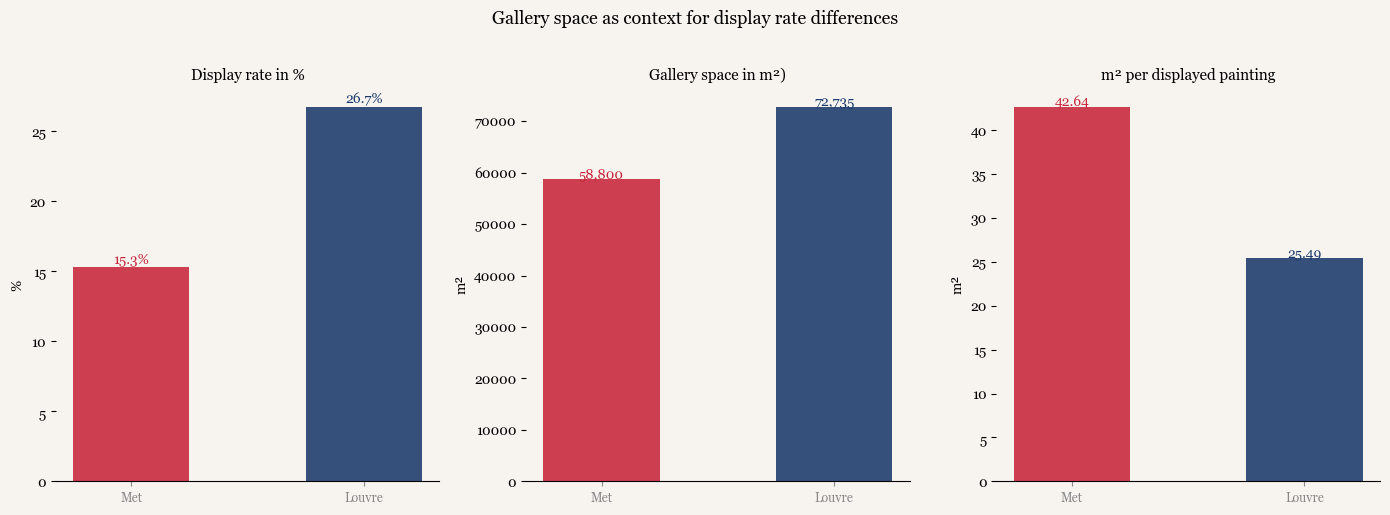

An interpretation:=

Met allocates 42.64 m² per displayed painting.
Louvre allocates 25.49 m² per displayed painting.
Met uses 67.3% more space per displayed painting than the Louvre.

This suggests Met is not displaying less because it lacks space —
it already uses more space per painting it does display. The lower
display rate more likely reflects collection size, curatorial policy,
conservation holdings, or storage decisions rather than physical capacity.

Note: with only two institutions, no statistical inference is possible.
Hence, these figures are background content only.


In [ ]:
#Visualising the space-adjusted comparison

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('#f7f4f0')

MET_COLOR    = '#C8253A'
LOUVRE_COLOR = '#1A3A6B'
colors = [MET_COLOR, LOUVRE_COLOR]

institutions = df_space['institution'].tolist()

#Drafting plot 1 - the display rate
axes[0].bar(institutions, df_space['display_rate_pct'], color=colors, alpha=0.88, width=0.5)
axes[0].set_title('Display rate in %', fontsize=11, fontfamily='serif')
axes[0].set_ylabel('%', fontsize=10)
for i, v in enumerate(df_space['display_rate_pct']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, color=colors[i])

#Now plot 2 - gallery space
axes[1].bar(institutions, df_space['gallery_space_m2'], color=colors, alpha=0.88, width=0.5)
axes[1].set_title('Gallery space in m²)', fontsize=11, fontfamily='serif')
axes[1].set_ylabel('m²', fontsize=10)
for i, v in enumerate(df_space['gallery_space_m2']):
     axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10, color=colors[i])

#Finally plot 3 - looking at m² per displayed painting (the normalised metric)
axes[2].bar(institutions, df_space['m2_per_displayed_painting'], color=colors, alpha=0.88, width=0.5)
axes[2].set_title('m² per displayed painting', fontsize=11, fontfamily='serif')
axes[2].set_ylabel('m²', fontsize=10)
for i, v in enumerate(df_space['m2_per_displayed_painting']):
    axes[2].text(i, v + 0.1, f'{v}', ha='center', fontsize=10, color=colors[i])

for ax in axes:
    ax.set_facecolor('#f7f4f0')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Gallery space as context for display rate differences',
             fontsize=13, fontfamily='serif', y=1.02)

plt.tight_layout()
plt.savefig('space_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

#Summary interpretation for analysis
print("An interpretation:=\n")
met_m2    = df_space['m2_per_displayed_painting'].iloc[0]
louvre_m2 = df_space['m2_per_displayed_painting'].iloc[1]
diff      = round(((met_m2 - louvre_m2) / louvre_m2) * 100, 1)

print(f"Met allocates {met_m2} m² per displayed painting.")
print(f"Louvre allocates {louvre_m2} m² per displayed painting.")
print(f"Met uses {diff}% more space per displayed painting than the Louvre.")
print()
print("This suggests Met is not displaying less because it lacks space —")
print("it already uses more space per painting it does display. The lower")
print("display rate more likely reflects collection size, curatorial policy,")
print("conservation holdings, or storage decisions rather than physical capacity.")
print()
print("Note: with only two institutions, no statistical inference is possible.")
print("Hence, these figures are background content only.")

In [ ]:
# Save the Louvre clean dataset with the recoded acquisition column included
# Note: df_louvre here is the version loaded from CSV in cell 28
# The recoded column was added to 'louvre' in cells 34-38
# Merging the recoded column back before saving
if 'acquisition_type_recoded' in louvre.columns:
    df_louvre['acquisition_type_recoded'] = louvre['acquisition_type_recoded'].values

df_louvre.to_csv("data/clean/louvre_paintings_clean.csv", index=False)
print(f"Exported {len(df_louvre)} rows to data/clean/louvre_paintings_clean.csv")
if 'acquisition_type_recoded' in df_louvre.columns:
    print(f"Recoded acquisition categories: {df_louvre['acquisition_type_recoded'].value_counts().to_dict()}")

#Summary

In this notebook:

1. Collected and analysed painting data from the Louvre museum as a comparative dataset against the Metropolitan Museum of Art.
2. Scraped ARK IDs for all 10,968 Louvre paintings from the collections search (already complete -- do not re-run).
3. Enriched each record via the Louvre JSON API to retrieve dimensions, acquisition details, subject tags, and location data (already complete -- do not re-run).
4. Generated display status from the room and current location fields -- a painting is classified as on display if a specific gallery location was recorded.

Before analysis, a data quality assessment confirmed no duplicate ARK IDs were present and that the is_on_display field contained only valid binary values. One start_year value was identified outside the plausible historical range. Null values were present across several fields, most notably dimensions and provenance, which is consistent with incomplete records typical of large museum datasets.

Feature engineering produced comparable variables to the Met dataset, including painting age, years in collection, canvas area, and standardised acquisition categories.

The comparative analysis found that the Louvre displays 26.7% of its paintings versus 15.3% at the Met. Acquisition type shows a moderate association with display status at both institutions, with Cramer's V of 0.257 at the Met and 0.133 at the Louvre when categories are recoded to equivalent buckets. Bequests outperform the institutional average at the Met, while the Louvre shows relatively even display rates across most acquisition types, suggesting acquisition route is a weaker predictor there than at the Met.

A contextual analysis of gallery floor space found that the Met allocates 42.64 m² per displayed painting versus 25.49 m² at the Louvre -- 67.3% more space per painting on show. This rules out physical capacity as the primary explanation for the Met's lower display rate, and points instead towards collection size, curatorial policy, and storage decisions as more likely drivers of the difference.

#Limitations

1. The Louvre API does not provide an explicit on-display flag. Display status is inferred from whether a room or gallery location is recorded. Paintings undergoing conservation, on loan, or temporarily relocated may be misclassified.
2. Louvre records 79 distinct acquisition modes in French. These have been consolidated into six English-equivalent categories to enable comparison with the Met. Some information is likely lost in this mapping, and 27 categories with fewer than ten paintings were absorbed into the Other bucket, which may obscure meaningful variation.
3. A substantial proportion of Louvre records lack height and width data, limiting the reliability of size-based comparisons between the two institutions.
4. The Louvre's higher overall display rate may reflect differences in gallery floor space, collection mandate, and operational model rather than curatorial preference alone. These structural factors are not controlled for in the analysis.
5. Both datasets represent a point-in-time snapshot. Gallery rotations, loans, and acquisitions will cause display status to drift from the recorded values over time.
6. Louvre data was collected via web scraping and an unofficial JSON API endpoint. Changes to the Louvre website structure or API would require the collection process to be rebuilt before the dataset could be refreshed.

Please note that the gallery space figures are approximate. Floor space data is sourced from Wikipedia and represents total gallery area rather than painting-specific hanging space. Both institutions also display sculptures, decorative arts, and other objects within their gallery areas, meaning the usable space for paintings specifically will be lower than the headline figures suggest. The m² per displayed painting metric should therefore be treated as indicative rather than precise.

In [ ]:
print(df_louvre.columns.tolist())
print(f"Shape: {df_louvre.shape}")
print(df_louvre.head(2))

['ark_id', 'url', 'title', 'collection', 'room', 'current_location', 'is_on_display', 'artist_name', 'artist_wikidata', 'height_cm', 'width_cm', 'materials_and_techniques', 'place_of_creation', 'provenance', 'acquisition_mode', 'acquisition_year', 'start_year', 'end_year', 'tags', 'tag_count', 'is_mnr', 'creation_year', 'painting_age', 'years_in_collection', 'area_cm2', 'has_known_artist', 'area_quartile', 'collection_age_band', 'acquisition_type_en']
Shape: (10673, 29)
        ark_id                                                url  \
0  cl010048442  https://collections.louvre.fr/ark:/53355/cl010...   
1  cl010049217  https://collections.louvre.fr/ark:/53355/cl010...   

                     title                                         collection  \
0  Tyché de Constantinople  Département des Arts de Byzance et des chrétie...   
1                 peinture             Département des Antiquités égyptiennes   

  room current_location  is_on_display artist_name artist_wikidata  heigh

In [ ]:
df_louvre['area_quartile'] = pd.cut(df_louvre['area_cm2'], 
    bins=[0, 1045, 3503, 8929, float('inf')],
    labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)'])

print(f"Remaining NaN in area_cm2: {df_louvre['area_cm2'].isna().sum()}")
print(f"Remaining NaN in area_quartile: {df_louvre['area_quartile'].isna().sum()}")

Remaining NaN in area_cm2: 10560
Remaining NaN in area_quartile: 10560


Redoing file for export and sorting NaN values in Louvre - based on age of painting being indicator of size where it's missing. E.g. paintings from a certain period are more likely to be a certain size, if it's not available. Also fixing department names from French to align better with Met and translating to English.

In [18]:
print(df_louvre['collection'].unique())

['Département des Arts de Byzance et des chrétientés en Orient'
 'Département des Antiquités égyptiennes' 'Département des Peintures'
 "Département des Objets d'art du Moyen Age, de la Renaissance et des temps modernes"
 'Département des Antiquités grecques, étrusques et romaines'
 "Département des Arts de l'Islam" 'Musée national Eugène-Delacroix'
 "Service de l'Histoire du Louvre"]


In [19]:
collection_translations = {
    'Département des Arts de Byzance et des chrétientés en Orient': 'Byzantine & Eastern Christian Art',
    'Département des Antiquités égyptiennes': 'Egyptian Antiquities',
    'Département des Peintures': 'Paintings',
    "Département des Objets d'art du Moyen Age, de la Renaissance et des temps modernes": 'Decorative Arts',
    'Département des Antiquités grecques, étrusques et romaines': 'Greek, Etruscan & Roman Antiquities',
    "Département des Arts de l'Islam": 'Islamic Art',
    'Musée national Eugène-Delacroix': 'Musée Delacroix',
    "Service de l'Histoire du Louvre": 'Louvre History Service'
}

df_louvre['collection_en'] = df_louvre['collection'].map(collection_translations).fillna(df_louvre['collection'])

print(df_louvre['collection_en'].unique())

['Byzantine & Eastern Christian Art' 'Egyptian Antiquities' 'Paintings'
 'Decorative Arts' 'Greek, Etruscan & Roman Antiquities' 'Islamic Art'
 'Musée Delacroix' 'Louvre History Service']


In [21]:
louvre_tableau_export = df_louvre[[
    'ark_id',
    'collection',
    'acquisition_type_en',
    'area_cm2',
    'area_quartile',
    'collection_age_band',
    'is_on_display',
    'creation_year'
]].copy()

louvre_tableau_export.to_csv('data/clean/louvre_tableau_export_en.csv', index=False)
print(f"Exported {len(louvre_tableau_export)} rows")
print(louvre_tableau_export.head())

Exported 10673 rows
        ark_id                                         collection  \
0  cl010048442  Département des Arts de Byzance et des chrétie...   
1  cl010049217             Département des Antiquités égyptiennes   
2  cl010052603                          Département des Peintures   
3  cl010052604                          Département des Peintures   
4  cl010052606                          Département des Peintures   

  acquisition_type_en  area_cm2 area_quartile collection_age_band  \
0               Other       NaN           NaN                100+   
1               Other       NaN           NaN               61-80   
2            Purchase       NaN           NaN               61-80   
3                Gift       NaN           NaN               61-80   
4            Purchase       NaN           NaN              81-100   

   is_on_display  creation_year  
0              0          624.5  
1              0            NaN  
2              0         1757.0  
3             

In [25]:
louvre_tableau_export = df_louvre[[
    'ark_id',
    'collection_en',
    'acquisition_type_en',
    'area_cm2',
    'area_quartile',
    'collection_age_band',
    'is_on_display',
    'creation_year'
]].copy()

louvre_tableau_export.to_csv('data/clean/louvre_tableau_export.csv', index=False)
print(f"Exported {len(louvre_tableau_export)} rows")
print(louvre_tableau_export['collection_en'].unique())

Exported 10673 rows
['Byzantine & Eastern Christian Art' 'Egyptian Antiquities' 'Paintings'
 'Decorative Arts' 'Greek, Etruscan & Roman Antiquities' 'Islamic Art'
 'Musée Delacroix' 'Louvre History Service']
